In [2]:
import squidpy as sq
import numpy as np
import pandas as pd
import scanpy as sc
import stan

In [3]:
adata = sc.datasets.visium_sge()
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_counts=2000)
adata.layers['raw'] = adata.X
adata

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


AnnData object with n_obs × n_vars = 3745 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'raw'

In [4]:
adata=stan.pp.tf_gene(adata,
                      min_cells_proportion = 0.2,
                      min_tfs_per_gene= 5,
                      min_genes_per_tf= 10,
                      max_proportion_genes_per_tf= 0.8,
                      tf_gene_source="hTFtarget",
                      tf_list="humantfs",
                      inplace = False,
                      source_dir="data/tf_gene/")
sc.pp.normalize_total(adata)
adata.layers['scaled'] = np.sqrt(adata.to_df())
stan.pp.assign_folds(adata, n_folds=10)
adata

/Users/aprilsagan/OneDrive - University of Pittsburgh/code/stan/stan/pp/tf_gene.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf_gene['values']=1


AnnData object with n_obs × n_vars = 3745 × 9021
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'fold'
    uns: 'spatial', 'tf_names'
    obsm: 'spatial'
    varm: 'tf_gene'
    layers: 'raw', 'scaled'

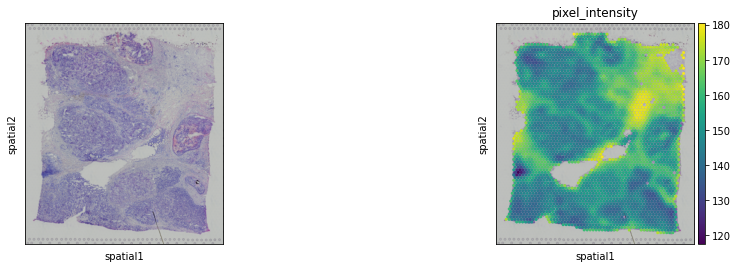

In [23]:
stan.pp.pixel_intensity(adata, window_size=30)
stan.pp.make_kernel(adata, n=500, im_feats_weight=0.25, banwidth=0.25)
sc.pl.spatial(adata, color=[None, "pixel_intensity"], size=1.5)

In [15]:
stl_model=stan.models.SpaTraFact_stl(adata, layer='scaled', intercept=False)
stl_model.fit(n_steps=5,
              stages=1,
              grid_search_params={'lambda1':[1e-6, 1e6]},
              axis=0,
              verbose=False)
print(stl_model.evaluate(fold=-1, return_string=True))
adata.obs['pred_cor_stl']=stl_model.evaluate(fold=-1)[0]
adata.var['pred_cor_stl']=stl_model.evaluate(fold=-1)[1]

adata.obsm['stl_tfa']=pd.DataFrame(stl_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

Sample Cor:0.233 Gene Cor: 0.165


In [24]:
stan_model=stan.models.SpaTraFact(adata, layer='scaled', intercept=False)
stan_model.fit(n_steps=5,
               stages=1,
               grid_search_params={'ls':[1e-6, 1e6],'lw':[1e-6, 1e10]},
               axis=0,
               verbose=False)
print(stan_model.evaluate(fold=-1, return_string=True))
adata.obs['pred_cor_stan']=stan_model.evaluate(fold=-1)[0]
adata.var['pred_cor_stan']=stan_model.evaluate(fold=-1)[1]

adata.obsm['stan_tfa']=pd.DataFrame(stan_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

Sample Cor:0.251 Gene Cor: 0.188


In [25]:
stan_model.params

{'ls': 1000.0, 'lw': 1000000.0}

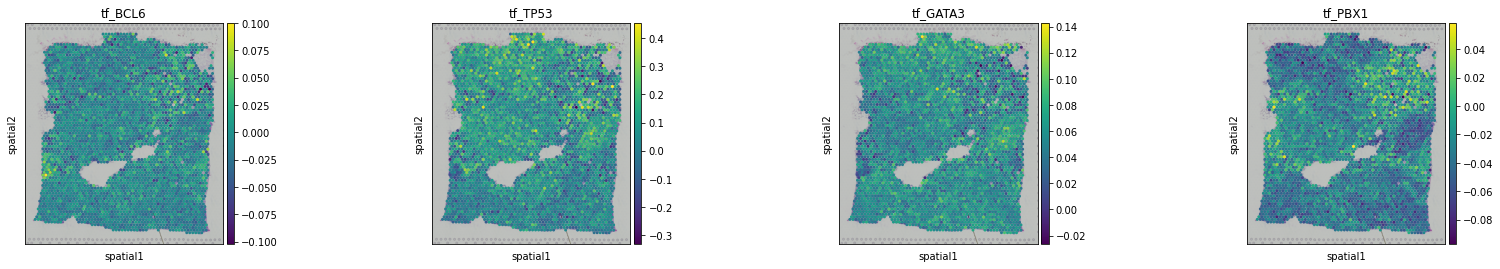

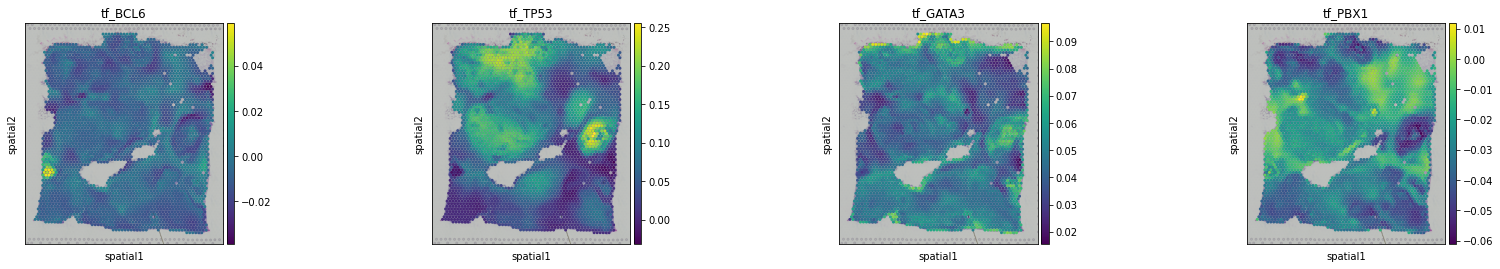

In [26]:
sc.pl.spatial(sq.pl.extract(adata, obsm_key='stl_tfa', prefix='tf'),
              color=['tf_BCL6', 'tf_TP53', "tf_GATA3", 'tf_PBX1'], size=1.5)
sc.pl.spatial(sq.pl.extract(adata, obsm_key='stan_tfa', prefix='tf'),
              color=['tf_BCL6', 'tf_TP53', "tf_GATA3", 'tf_PBX1'], size=1.5)

In [27]:
from anndata import AnnData
#adata.uns['tf_names'] = adata.uns['tf_names'].to_list()
adata_tfa = AnnData(
    X=adata.obsm['stan_tfa'],
    obs=adata.obs,
    obsm={name: obj for (name, obj) in adata.obsm.items() if "tf" not in name},
    layers={name: obj for (name, obj) in adata.obsm.items() if "tf" in name}
)

adata_tfa.uns = adata.uns


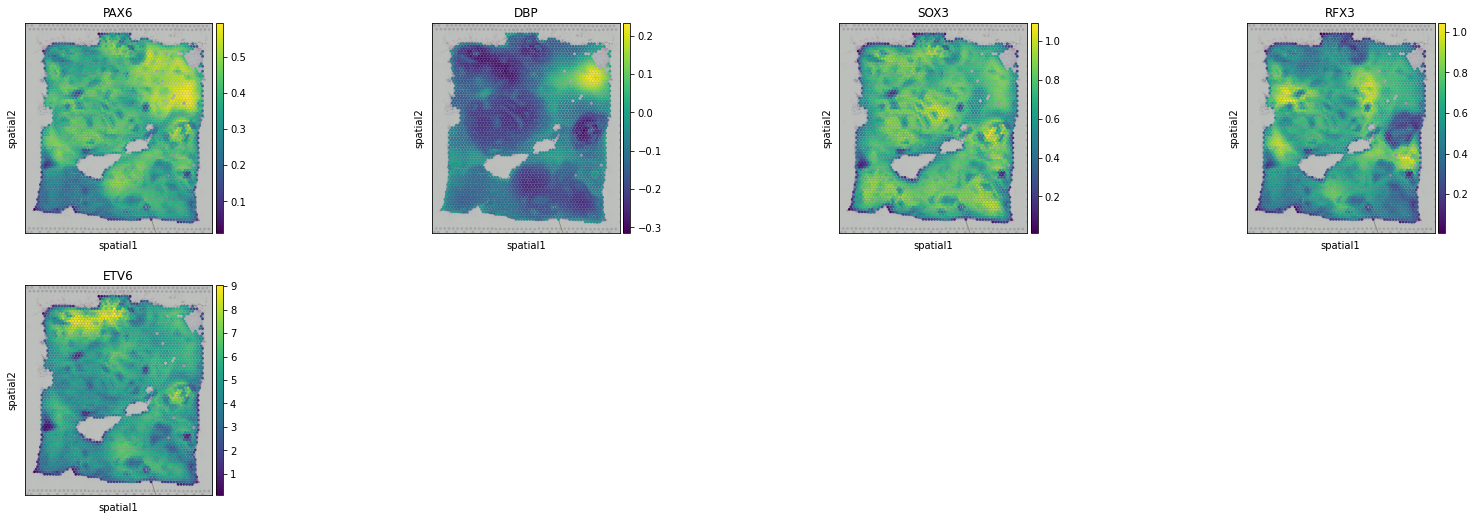

In [30]:
sc.pl.spatial(adata_tfa, color=adata_tfa.to_df().std().sort_values().tail(5).index, size=1.5)


In [12]:
!mkdir out /
adata.write("out/stf_results.h5ad")
adata_tfa.write("out/stf_results_tfa_only.h5ad")

mkdir: out: File exists
mkdir: /: Is a directory


Text(0.5, 0, '')

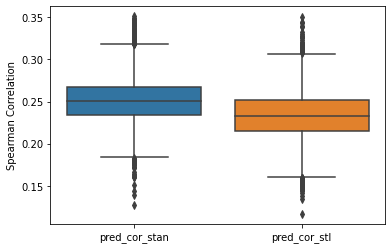

In [13]:
import seaborn as sns
from matplotlib import pyplot as plt
sns.boxplot(data=adata_tfa.obs[[ "pred_cor_stan","pred_cor_stl"]].melt(), x='variable', y='value')
plt.ylabel("Spearman Correlation")
plt.xlabel("")